<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Air-Quality-_PM-2.5/Iteration_PM_2_5_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

In [2]:
path = "/content/drive/MyDrive/Research v2/Research 18.03.2026/PM 2.5/final_pm25_dataset.csv"

pm25_df = pd.read_csv(path)

In [3]:
target = "air_quality_PM2.5"

selected_features = [col for col in pm25_df.columns if col != target]

In [4]:
split_index = int(0.8 * len(pm25_df))

train_df = pm25_df.iloc[:split_index].copy()
test_df  = pm25_df.iloc[split_index:].copy()

In [5]:
n_train = len(train_df)

iter1 = train_df.iloc[:int(0.33*n_train)].copy()
iter2 = train_df.iloc[int(0.33*n_train):int(0.66*n_train)].copy()
iter3 = train_df.iloc[int(0.66*n_train):].copy()

In [6]:
def get_xy(data):
    X = data[selected_features]
    y = data[target]
    return X, y

In [7]:
X1, y1 = get_xy(iter1)
X2, y2 = get_xy(iter2)
X3, y3 = get_xy(iter3)

X_test, y_test = get_xy(test_df)

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Iteration 1
rf_model.fit(X1, y1)

# Iteration 2
X12 = pd.concat([X1, X2])
y12 = pd.concat([y1, y2])

rf_model.fit(X12, y12)

# Iteration 3
X123 = pd.concat([X1, X2, X3])
y123 = pd.concat([y1, y2, y3])

rf_model.fit(X123, y123)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [9]:
!pip install shap -q

In [10]:
import shap

shap.initjs()

In [11]:
explainer = shap.TreeExplainer(rf_model)

In [12]:
X_sample = X_test.sample(1000, random_state=42)

In [14]:
shap_values = explainer.shap_values(X_sample)

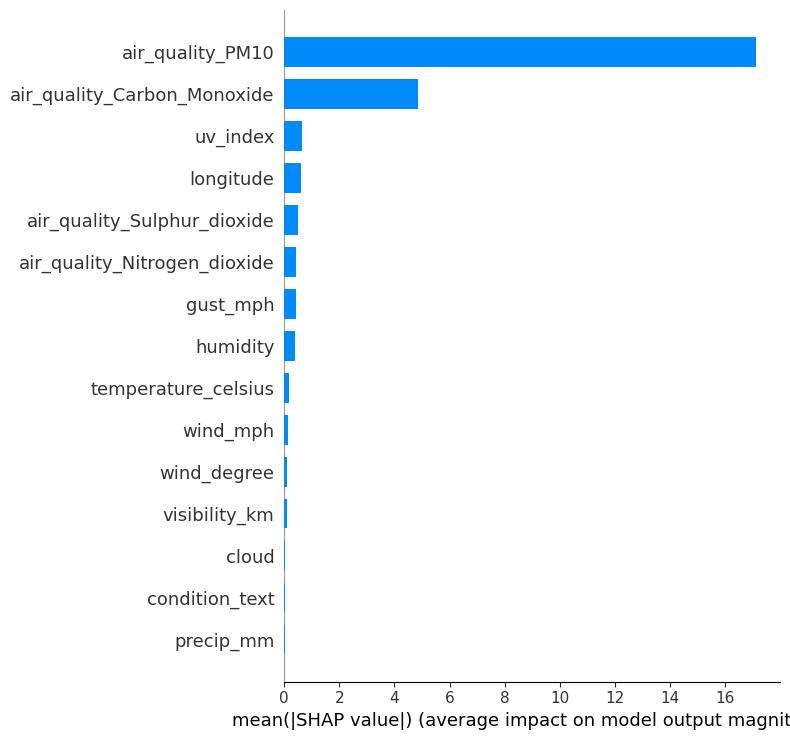

In [16]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    feature_names=X_sample.columns
)

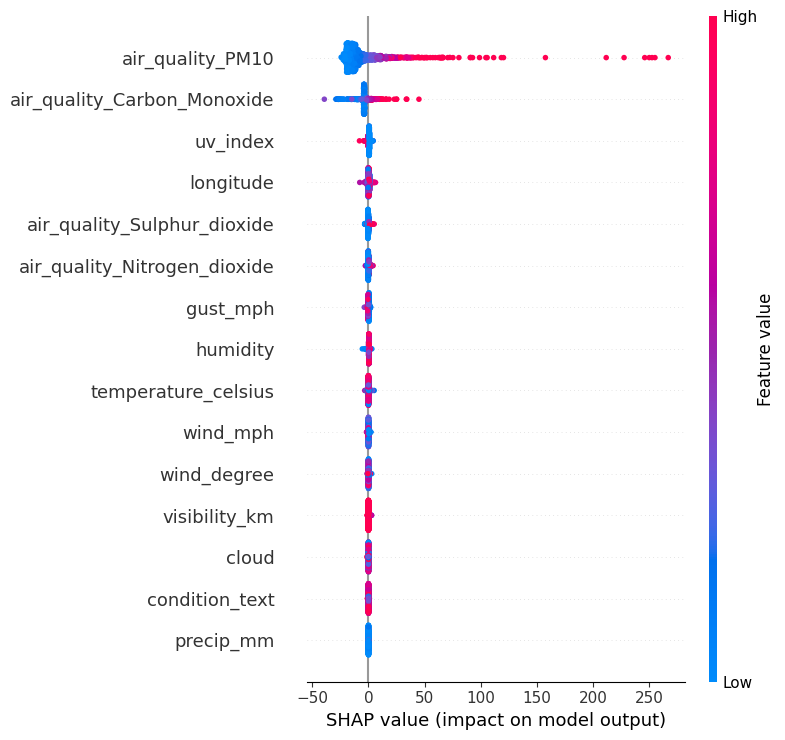

In [15]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X_sample.columns
)

In [18]:
importance = np.abs(shap_values).mean(axis=0)

top_features = X_sample.columns[np.argsort(importance)[::-1][:3]]

print(top_features)

Index(['air_quality_PM10', 'air_quality_Carbon_Monoxide', 'uv_index'], dtype='object')


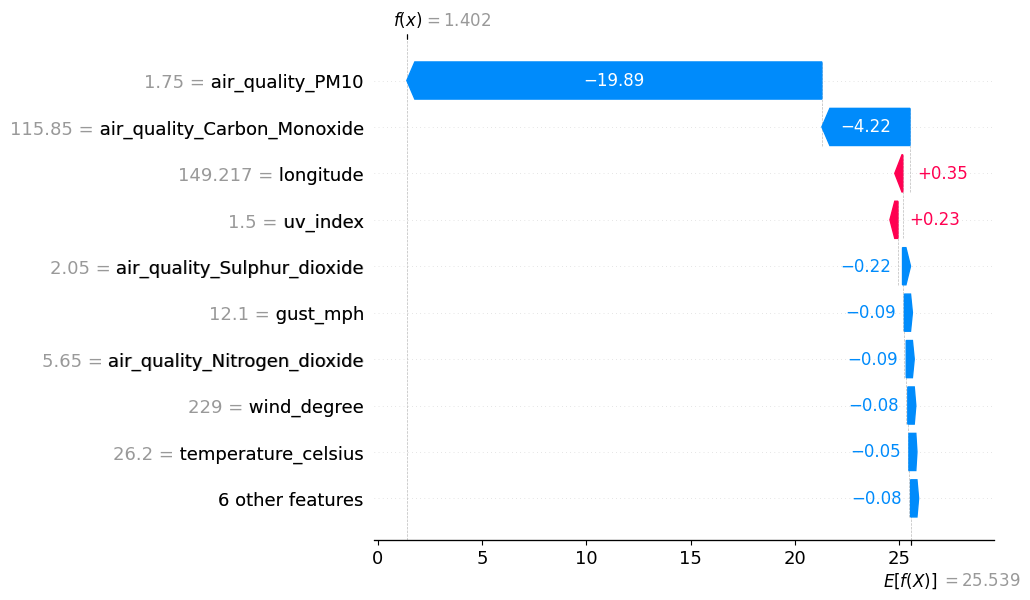

In [17]:
sample_index = 0

explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_sample.iloc[sample_index],
    feature_names=X_sample.columns
)

shap.plots.waterfall(explanation)

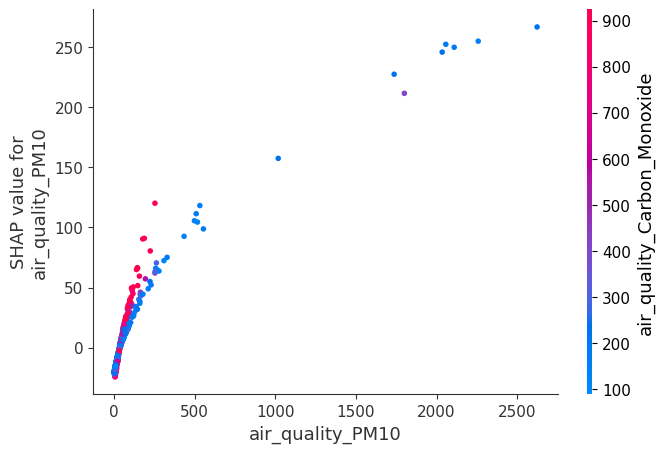

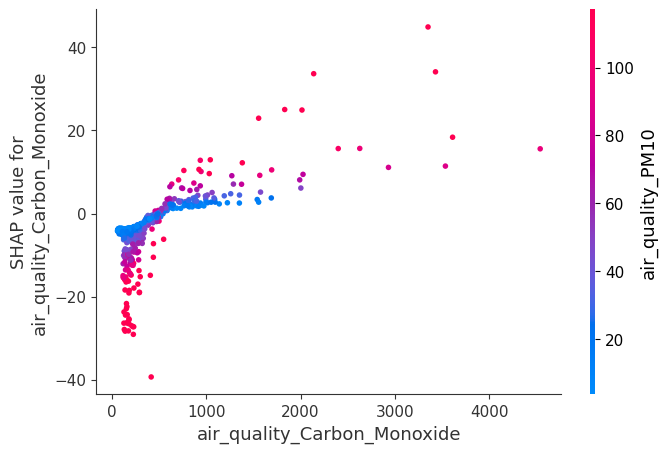

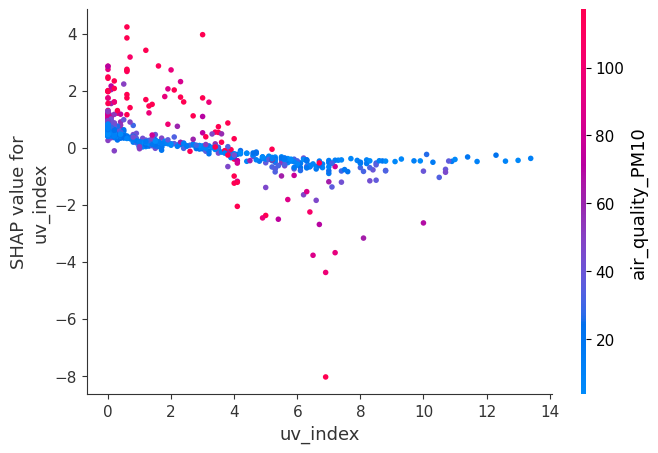

In [19]:
for feature in top_features:
    shap.dependence_plot(
        feature,
        shap_values,
        X_sample
    )

In [ ]:
interaction_values = explainer.shap_interaction_values(X_sample)

shap.dependence_plot(
    top_features[0],
    interaction_values,
    X_sample,
    interaction_index=top_features[1]
)